# Evaluación 1 – Calidad y Preparación de Datos
---

## Descripción

Diagnóstico de calidad, análisis exploratorio y preparación (limpieza y transformación) del set de datos `rendimiento_academico_evaluacion.csv`, correspondiente al rendimiento académico de estudiantes de una institución de educación superior.

## Objetivo

Diagnosticar la calidad de los datos, realizar un análisis exploratorio, responder las preguntas de investigación planteadas y, a partir de lo anterior, definir e implementar (mediante `Pipeline` y `ColumnTransformer` de scikit-learn) las estrategias de tratamiento que permitan obtener un dataset final limpio, exportado como `rendimiento_academico_limpio.csv`.

# Fuente de datos

In [1]:
!wget https://raw.githubusercontent.com/JRiquelmeP/C1-IA/main/rendimiento_academico_evaluacion.csv

--2026-09-04 03:54:51--  https://raw.githubusercontent.com/JRiquelmeP/C1-IA/main/rendimiento_academico_evaluacion.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 382638 (374K) [text/plain]
Saving to: ‘rendimiento_academico_evaluacion.csv’

rendimiento_academi 100%[===================>] 373.67K  --.-KB/s    in 0.04s   

2026-09-04 03:54:51 (10.0 MB/s) - ‘rendimiento_academico_evaluacion.csv’ saved [382638/382638]



In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)

In [3]:
data = pd.read_csv("rendimiento_academico_evaluacion.csv")
data.shape

(5100, 11)

# Contexto

Una institución de educación superior desea analizar el rendimiento académico de sus estudiantes. El set de datos contiene información demográfica (`Age`), hábitos de estudio y estilo de vida (`StudyHours`, `SleepHours`, `InternetHours`, `Attendance`), antecedentes académicos (`PreviousGPA`, `AssignmentsCompleted`), condición socioeconómica (`Scholarship`), programa académico (`Program`) y el resultado final del curso (`FinalGrade`).

Antes de utilizar estos datos en análisis o modelos predictivos, es necesario diagnosticar su calidad y prepararlos adecuadamente.

# Metadata

| Variable | Tipo de dato | Naturaleza | Descripción | Dominio / Restricciones conocidas |
| --- | --- | --- | --- | --- |
| `StudentID` | Texto (`string`) | Nominal / Identificador | Código único del estudiante. | Estructura `STU-XXXXX`. No tiene valor predictivo; se excluye del modelamiento. |
| `Age` | Numérica (`float`) | Continua | Edad del estudiante en años. | Estudiantes de educación superior (incluye educación continua). Se define un rango plausible entre 17 y 65-70 años; edades mayores son posibles pero atípicas. |
| `StudyHours` | Numérica (`float`) | Continua | Horas de estudio dedicadas **por semana**. | Una semana tiene 168 horas, por lo que el valor no puede ser negativo ni superar 168 (en la práctica, valores muy por sobre ~80-100 horas semanales ya son extremadamente inusuales). |
| `Attendance` | Numérica (`float`) | Continua | Porcentaje de asistencia a clases. | Debe estar entre 0 y 100 (%). |
| `PreviousGPA` | Numérica (`float`) | Continua | Promedio académico previo. | Rango 1.0 a 10.0. |
| `AssignmentsCompleted` | Numérica (`float`) | Continua | Porcentaje de tareas/actividades completadas. | Debe estar entre 0 y 100 (%). |
| `SleepHours` | Numérica (`float`) | Continua | Horas de sueño **por día**. | Entre 0 y 24 horas. |
| `InternetHours` | Numérica (`float`) | Continua | Horas de uso de internet **por día**. | Entre 0 y 24 horas. |
| `Scholarship` | Categórica (`object`) | Nominal | Indica si el estudiante posee beca. | Valores esperados: `Sí` / `No`. |
| `Program` | Categórica (`object`) | Nominal | Programa académico que cursa el estudiante. | 5 programas: Ingeniería Informática, Ingeniería Industrial, Ingeniería Civil, Administración, Contador Auditor. |
| `FinalGrade` | Numérica (`float`) | Continua | Calificación final del curso. | Rango 1.0 a 10.0. **Variable objetivo.** |


# 1. Diagnóstico de calidad de datos

## 1.1 Caracterización del dataset

In [4]:
data.shape

(5100, 11)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             5100 non-null   object 
 1   Age                   4997 non-null   float64
 2   StudyHours            4919 non-null   float64
 3   Attendance            4876 non-null   float64
 4   PreviousGPA           4938 non-null   float64
 5   AssignmentsCompleted  4884 non-null   float64
 6   SleepHours            4978 non-null   float64
 7   InternetHours         4924 non-null   float64
 8   Scholarship           5019 non-null   object 
 9   Program               5030 non-null   object 
 10  FinalGrade            5100 non-null   float64
dtypes: float64(8), object(3)
memory usage: 438.4+ KB


In [6]:
variables_numericas = ["Age", "StudyHours", "Attendance", "PreviousGPA",
                       "AssignmentsCompleted", "SleepHours", "InternetHours", "FinalGrade"]
variables_categoricas = ["Scholarship", "Program"]
variable_id = "StudentID"
variable_objetivo = "FinalGrade"

print(f"Cantidad de registros: {data.shape[0]}")
print(f"Cantidad de variables: {data.shape[1]}")
print(f"\nVariables numéricas (continuas) ({len(variables_numericas)}): {variables_numericas}")
print(f"Variables categóricas ({len(variables_categoricas)}): {variables_categoricas}")
print(f"\nVariable identificadora: {variable_id}")
print(f"Variable de resultado académico (objetivo): {variable_objetivo}")

Cantidad de registros: 5100
Cantidad de variables: 11

Variables numéricas (continuas) (8): ['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours', 'FinalGrade']
Variables categóricas (2): ['Scholarship', 'Program']

Variable identificadora: StudentID
Variable de resultado académico (objetivo): FinalGrade


**Interpretación**

El dataset contiene **5.100 registros** y **11 variables**. `StudentID` corresponde al **identificador único** de cada estudiante (no aporta valor predictivo). `FinalGrade` corresponde al **resultado académico** (nota final), variable objetivo del análisis.

De las 11 variables, **8 son numéricas** (`Age`, `StudyHours`, `Attendance`, `PreviousGPA`, `AssignmentsCompleted`, `SleepHours`, `InternetHours`, `FinalGrade`) y **2 son categóricas** (`Scholarship`, `Program`). Todas las variables numéricas están almacenadas como `float64`, incluso aquellas que conceptualmente son porcentajes o notas.

## 1.2 Valores faltantes

In [7]:
null_summary = pd.DataFrame(
    {
        "Nulos_Absolutos": data.isnull().sum(),
        "Porcentaje_Nulos": round((data.isnull().sum() / len(data)) * 100, 2),
    }
)
null_summary[null_summary["Nulos_Absolutos"] > 0].sort_values("Nulos_Absolutos", ascending=False)

,Nulos_Absolutos,Porcentaje_Nulos
Attendance,224,4.39
AssignmentsCompleted,216,4.24
StudyHours,181,3.55
InternetHours,176,3.45
PreviousGPA,162,3.18
SleepHours,122,2.39
Age,103,2.02
Scholarship,81,1.59
Program,70,1.37


In [8]:
data.isnull().sum(axis=1)
data["nulos_en_fila"] = data.isnull().sum(axis=1)
data.isnull().sum(axis=1).value_counts()

,count
0,3920
1,1030
2,145
3,5


In [9]:
conteo = data.isnull().sum(axis=1).value_counts()

porcentaje = data.isnull().sum(axis=1).value_counts(normalize=True) * 100

resumen_nulos = pd.DataFrame({
    'Cantidad de Filas': conteo,
    'Porcentaje (%)': porcentaje
}).round(2)

display(resumen_nulos)

,Cantidad de Filas,Porcentaje (%)
0,3920,76.86
1,1030,20.20
2,145,2.84
3,5,0.10


**Interpretación**

Nueve de las once variables presentan valores faltantes, en un rango que va desde el 1,37% (`Program`) hasta el 4,39% (`Attendance`). Las variables con **mayor cantidad de datos faltantes** son `Attendance` (224, 4,39%), `AssignmentsCompleted` (216, 4,24%) y `StudyHours` (181, 3,55%). Solo `StudentID` y `FinalGrade` (la variable objetivo) no presentan valores nulos.

**Análisis a nivel de fila:** En este caso, la distribución de nulos por fila resulta favorable para optar por imputación: **76,9% de las filas están 100% completas** (3.920 filas), **20,2% tiene solo 1 valor faltante** (1.030 filas), **2,8% tiene 2 valores faltantes** (145 filas) y apenas **0,1% tiene 3 valores faltantes** (5 filas). No hay filas con una proporción alta de campos vacíos, por lo que no se justifica descartar registros completos: la imputación conserva información real en la gran mayoría de los casos y afecta, como máximo, a 2-3 de las 11 variables dentro de un mismo registro.

Adicionalmente, se verificó que `FinalGrade`, la variable objetivo, no presenta valores nulos, por lo que no es necesario descartar ni imputar filas.

**Estrategia de tratamiento:** dado que la proporción de faltantes es baja en todas las variables (< 5%) y la gran mayoría de las filas están completas o con a lo sumo 1-2 valores ausentes, se optará por **imputación**: media o mediana (según la presencia de atípicos, ver 1.5) para las variables numéricas, y moda para las categóricas. No se justifica eliminar filas ni columnas, ya que se perdería información valiosa de forma innecesaria (ver justificación detallada en la Sección 3).

## 1.3 Registros duplicados

In [10]:
total_duplicates = data.duplicated().sum()
print(f"Cantidad de filas totalmente duplicadas: {total_duplicates}")

porcentaje_duplicados = (total_duplicates / len(data)) * 100
print(f"Porcentaje de filas duplicadas: {porcentaje_duplicados:.2f}%")

Cantidad de filas totalmente duplicadas: 100
Porcentaje de filas duplicadas: 1.96%


In [11]:
duplicados_por_id = data.duplicated(subset=["StudentID"]).sum()
print(f"Duplicados considerando solo StudentID: {duplicados_por_id}")
print(f"StudentID únicos: {data['StudentID'].nunique()} de {len(data)} registros")

Duplicados considerando solo StudentID: 100
StudentID únicos: 5000 de 5100 registros


**Interpretación**

Se identificaron **100 registros duplicados** (1,96% del dataset), correspondientes a filas **completamente idénticas** en todas sus columnas. La variable natural para identificar de forma única a un registro es `StudentID`: la cantidad de duplicados detectada por `StudentID` coincide exactamente con la detectada por fila completa, lo que confirma que se trata de la **misma observación repetida**, y no de dos estudiantes distintos que comparten valores por azar.

**Decisión:** eliminar los registros duplicados, conservando la primera ocurrencia (`keep="first"`). Al ser copias exactas, no aportan información nueva; mantenerlos sobrerrepresentaría a esos estudiantes en las estadísticas descriptivas y en cualquier modelo posterior.

## 1.4 Inconsistencias

In [12]:
regla_attendance = (data["Attendance"] < 0) | (data["Attendance"] > 100)
regla_sleep = (data["SleepHours"] < 0) | (data["SleepHours"] > 24)
regla_internet = (data["InternetHours"] < 0) | (data["InternetHours"] > 24)
regla_study = (data["StudyHours"] < 0) | (data["StudyHours"] > 168)
regla_gpa = (data["PreviousGPA"] < 1) | (data["PreviousGPA"] > 10)
regla_finalgrade = (data["FinalGrade"] < 1) | (data["FinalGrade"] > 10)
regla_age = (data["Age"] < 17) | (data["Age"] > 100)
regla_assignments = (data["AssignmentsCompleted"] < 0) | (data["AssignmentsCompleted"] > 100)

inconsistencias_numericas = pd.DataFrame({
    "Variable": ["Attendance", "SleepHours", "InternetHours", "StudyHours", "PreviousGPA", "FinalGrade", "Age", "AssignmentsCompleted"],
    "Problema": [
        "Porcentaje fuera del rango [0, 100]",
        "Horas de sueño diarias fuera de [0, 24]",
        "Horas de uso de internet diarias fuera de [0, 24]",
        "Horas de estudio semanales fuera de [0, 168]",
        "Promedio previo fuera de la escala [1.0, 10.0]",
        "Nota fuera de la escala [1.0, 10.0]",
        "Edad fuera del rango [17, 100]",
        "Tareas completadas fuera del rango [0, 100]"
    ],
    "Cantidad": [regla_attendance.sum(), regla_sleep.sum(), regla_internet.sum(), regla_study.sum(), regla_gpa.sum(), regla_finalgrade.sum(), regla_age.sum(), regla_assignments.sum()],
})
inconsistencias_numericas["Porcentaje"] = round(inconsistencias_numericas["Cantidad"] / len(data) * 100, 2)
inconsistencias_numericas

,Variable,Problema,Cantidad,Porcentaje
0,Attendance,"Porcentaje fuera del rango [0, 100]",20,0.39
1,SleepHours,"Horas de sueño diarias fuera de [0, 24]",8,0.16
2,InternetHours,"Horas de uso de internet diarias fuera de [0, 24]",31,0.61
3,StudyHours,"Horas de estudio semanales fuera de [0, 168]",0,0.00
4,PreviousGPA,"Promedio previo fuera de la escala [1.0, 10.0]",0,0.00
5,FinalGrade,"Nota fuera de la escala [1.0, 10.0]",4,0.08
6,Age,"Edad fuera del rango [17, 100]",0,0.00
7,AssignmentsCompleted,"Tareas completadas fuera del rango [0, 100]",0,0.00


In [13]:
# Registros con al menos una inconsistencia numérica
inconsistentes = data[regla_attendance | regla_sleep | regla_internet | regla_study | regla_gpa | regla_finalgrade | regla_age | regla_assignments]
print(f"Registros con al menos una inconsistencia numérica: {len(inconsistentes)}")
inconsistentes.head()


Registros con al menos una inconsistencia numérica: 62


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade,nulos_en_fila
5,STU-11440,21.0,13.81,-19.961240,6.69,93.82,5.72,5.150000,Sí,Ingeniería Industrial,4.650000,0
16,STU-13555,26.0,6.08,111.567467,4.69,73.54,NaN,6.440000,No,Ingeniería Civil,3.050000,1
237,STU-10593,23.0,18.68,88.640000,6.69,100.00,5.34,68.116278,Sí,Ingeniería Industrial,4.910000,0
263,STU-12872,NaN,12.20,80.960000,5.54,81.02,6.82,1.530000,No,Ingeniería Civil,-1.328245,1
308,STU-14461,28.0,11.88,80.410000,5.61,76.94,7.33,48.616835,No,Contador Auditor,4.060000,0


In [14]:
# Inconsistencias de formato en variables categóricas
print("Valores únicos de Scholarship:")
print(data["Scholarship"].value_counts(dropna=False))
print()
print("Valores únicos de Program:")
print(data["Program"].value_counts(dropna=False))

Valores únicos de Scholarship:
Scholarship
No     3364
Sí     1620
NaN      81
si       10
No       10
NO        8
SÍ        5
SI        2
Name: count, dtype: int64

Valores únicos de Program:
Program
Ingeniería Informática     1424
Ingeniería Industrial      1119
Ingeniería Civil           1004
Administración              787
Contador Auditor            660
NaN                          70
Ingenieria Informatica       10
INGENIERÍA INFORMÁTICA        7
Ingeniería Civil              5
INGENIERÍA CIVIL              4
Ingeniería informática        4
ADMINISTRACIÓN                3
Administracion                3
Name: count, dtype: int64


**Interpretación**

Se identificaron dos tipos de inconsistencias:

**a) Valores fuera de dominio (numéricas):**

| Variable | Problema | Cantidad | Estrategia propuesta |
| --- | --- | --- | --- |
| `Attendance` | Porcentaje negativo o superior a 100% (imposible, dado que es un porcentaje de asistencia) | 20 (0,39%) | Recodificar a `NaN` y tratar como valor faltante (imputación) |
| `SleepHours` | Horas de sueño diarias negativas (físicamente imposible) | 8 (0,16%) | Recodificar a `NaN` e imputar |
| `InternetHours` | Horas diarias de uso de internet superiores a 24 (un día tiene 24 horas) | 31 (0,61%) | Recodificar a `NaN` e imputar |
| `StudyHours` | Horas de estudio semanales superiores a 168 (imposible en una sola semana) | 0 (0,00%) | Se mantiene la regla como control de calidad; en este dataset no se detectan casos que la infrinjan |
| `PreviousGPA` | Promedio fuera de la escala 1,0–10,0 | *(ver `regla_gpa` en la tabla generada arriba)* | Recodificar a `NaN` e imputar |
| `FinalGrade` | Nota fuera de la escala 1,0–10,0 (imposible en el sistema de evaluación) | 4 (0,08%) | Recodificar a `NaN` e imputar (mediana) |

Estos valores no corresponden a comportamientos extremos, sino a **valores lógicamente imposibles** dado el significado de cada variable (un porcentaje no puede ser negativo, un día no tiene más de 24 horas, una semana no tiene más de 168 horas, una nota o un promedio no puede exceder la escala oficial). Por ello se tratan como errores de captura y no como atípicos válidos. A diferencia de las demás, `StudyHours` no presenta violaciones de dominio en este dataset (0 casos); sus valores más altos, revisados en la Sección 1.5, corresponden a atípicos válidos y no a errores de captura.

**b) Inconsistencias de formato (categóricas):** `Scholarship` presenta 8 valores únicos en lugar de 2 (`Sí`/`No`), producto de variaciones de mayúsculas, minúsculas, tildes y espacios en blanco (`si`, `SI`, `NO`, `No `, `SÍ `). Lo mismo ocurre con `Program`, que presenta 13 valores únicos en lugar de 5, por las mismas razones (p. ej. `INGENIERÍA INFORMÁTICA`, `Ingenieria Informatica`, `Ingeniería Civil ` con espacio final). **Estrategia:** normalizar mayúsculas/minúsculas, tildes y espacios, consolidando cada variante en su categoría correspondiente (no son categorías nuevas, sino errores de formato de la misma categoría).




## 1.5 Valores atípicos

In [15]:
def diagnostico_outliers_iqr(dataframe: pd.DataFrame, columna: str):
  """
  Diagnóstico de valores atípicos mediante el método del rango intercuartílico (IQR).

  Parámetros
  ----------
  dataframe: pd.DataFrame
    Set de datos a analizar
  columna: str
    Nombre de la columna a analizar

  Retorna
  -------
  outliers: pd.DataFrame
    Registros atípicos encontrados
  """
  Q1 = dataframe[columna].quantile(0.25)
  Q3 = dataframe[columna].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = dataframe[
        (dataframe[columna] < lower_bound) | (dataframe[columna] > upper_bound)
  ]

  print(f"--- Análisis IQR para la variable '{columna}' ---")
  print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
  print(f"Límite Inferior: {lower_bound:.2f} | Límite Superior: {upper_bound:.2f}")
  print(f"Registros fuera de límites: {len(outliers)} ({(len(outliers)/len(dataframe))*100:.2f}%)\n")
  return outliers

In [16]:
for var in variables_numericas:
    _ = diagnostico_outliers_iqr(data, var)

--- Análisis IQR para la variable 'Age' ---
Q1: 21.00 | Q3: 26.00 | IQR: 5.00
Límite Inferior: 13.50 | Límite Superior: 33.50
Registros fuera de límites: 63 (1.24%)

--- Análisis IQR para la variable 'StudyHours' ---
Q1: 8.75 | Q3: 15.44 | IQR: 6.69
Límite Inferior: -1.29 | Límite Superior: 25.48
Registros fuera de límites: 49 (0.96%)

--- Análisis IQR para la variable 'Attendance' ---
Q1: 77.58 | Q3: 93.01 | IQR: 15.43
Límite Inferior: 54.43 | Límite Superior: 116.16
Registros fuera de límites: 27 (0.53%)

--- Análisis IQR para la variable 'PreviousGPA' ---
Q1: 5.22 | Q3: 6.23 | IQR: 1.01
Límite Inferior: 3.70 | Límite Superior: 7.75
Registros fuera de límites: 21 (0.41%)

--- Análisis IQR para la variable 'AssignmentsCompleted' ---
Q1: 75.85 | Q3: 100.00 | IQR: 24.15
Límite Inferior: 39.62 | Límite Superior: 136.23
Registros fuera de límites: 17 (0.33%)

--- Análisis IQR para la variable 'SleepHours' ---
Q1: 6.16 | Q3: 7.86 | IQR: 1.70
Límite Inferior: 3.61 | Límite Superior: 10.41
R

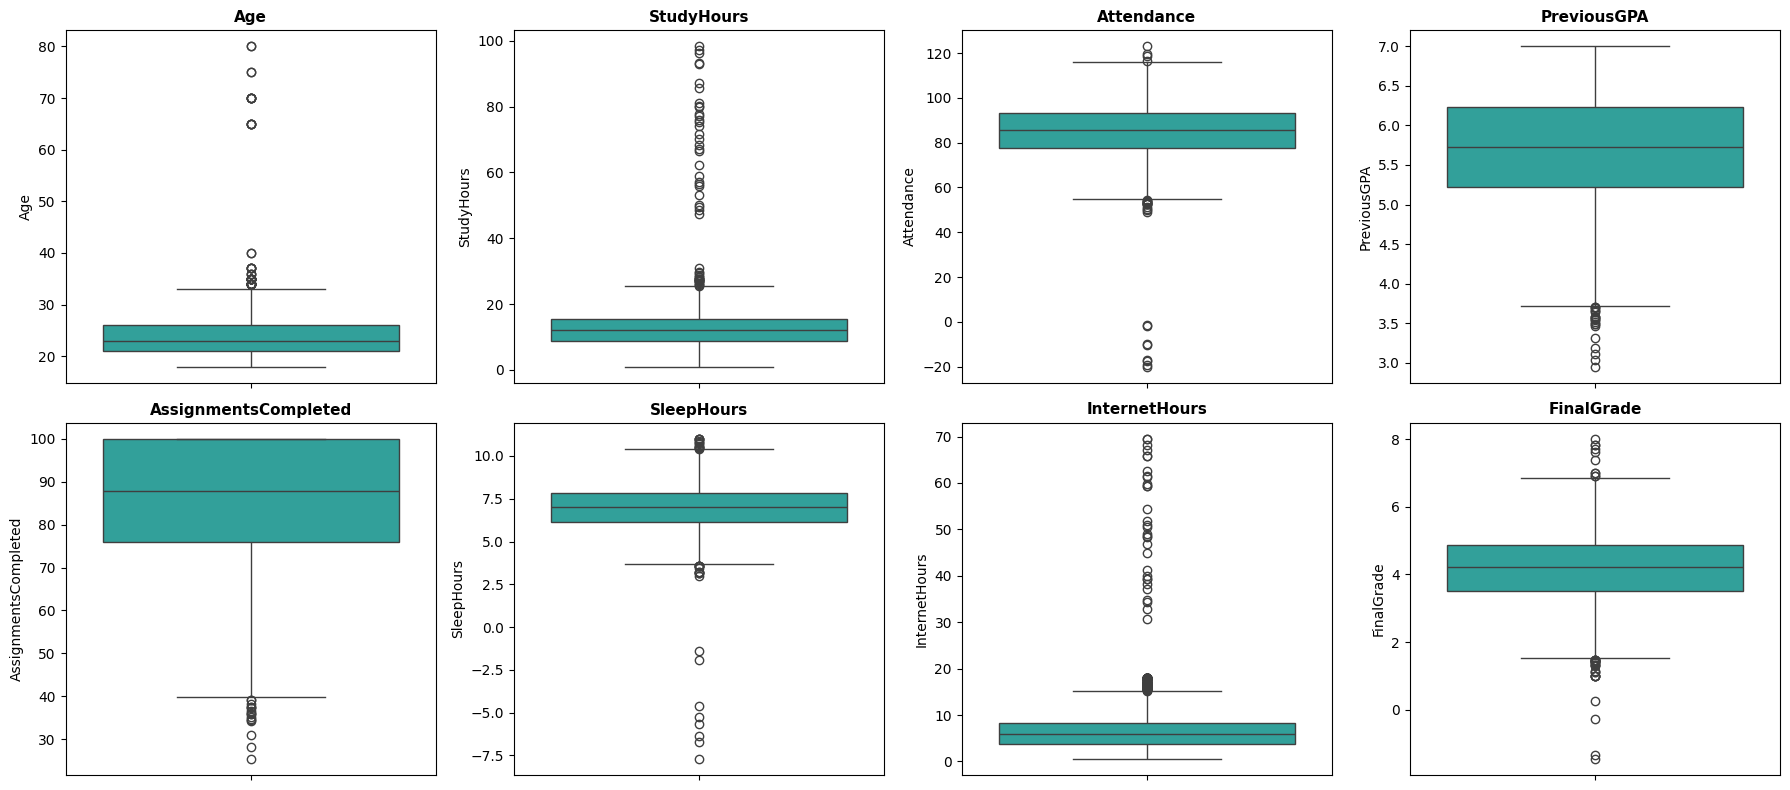

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, var in enumerate(variables_numericas):
    sns.boxplot(y=data[var], ax=axes[i], color="lightseagreen")
    axes[i].set_title(var, fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretación**

El método IQR detecta valores atípicos en las 8 variables numéricas, con proporciones que van desde 0,33% (`AssignmentsCompleted`) hasta 2,84% (`InternetHours`). Es importante **diferenciar entre valor extremo (válido) y valor inválido**:

- **Valores inválidos** (fuera del dominio posible de la variable): corresponden a los ya identificados en la Sección 1.4 (`Attendance`, `SleepHours`, `InternetHours`, `FinalGrade`). Un ejemplo claro es `Attendance`: el límite superior del IQR es de aproximadamente 116,2%, pero el porcentaje de asistencia no puede superar 100% ni ser negativo; existen 20 registros (0,39%) fuera de ese dominio — estos **no son atípicos estadísticos "normales", son errores**. `StudyHours` se evaluó bajo la misma lógica (límite físico de 168 horas semanales), pero en este dataset no se registran casos que lo superen (0 casos).
- **Valores atípicos válidos** (extremos, pero dentro del dominio posible): por ejemplo, `Age` presenta estudiantes de hasta 80 años; si bien son poco frecuentes (educación continua/adultos), no son imposibles. Del mismo modo, `InternetHours` tiene 145 registros (2,84%) fuera de los límites del IQR, pero solo 31 de ellos superan las 24 horas (inválidos); el resto son estudiantes con un uso de internet elevado pero plausible (entre ~15 y 24 horas).

**Estrategia de tratamiento:** los valores inválidos se recodifican como faltantes y se imputan (igual que 1.4). Los valores atípicos válidos **no se eliminan** (son observaciones reales), pero se atenúa su influencia utilizando escalado robusto en las variables con mayor proporción de atípicos (`Age`, `StudyHours`).




# 2. Análisis exploratorio de datos

## Tipos de datos

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             5100 non-null   object 
 1   Age                   4997 non-null   float64
 2   StudyHours            4919 non-null   float64
 3   Attendance            4876 non-null   float64
 4   PreviousGPA           4938 non-null   float64
 5   AssignmentsCompleted  4884 non-null   float64
 6   SleepHours            4978 non-null   float64
 7   InternetHours         4924 non-null   float64
 8   Scholarship           5019 non-null   object 
 9   Program               5030 non-null   object 
 10  FinalGrade            5100 non-null   float64
 11  nulos_en_fila         5100 non-null   int64  
dtypes: float64(8), int64(1), object(3)
memory usage: 478.3+ KB


## Estadísticas descriptivas – variables numéricas

In [19]:
data.drop(columns=["StudentID"]).describe().round(2)

,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,FinalGrade,nulos_en_fila
count,4997.00,4919.00,4876.00,4938.00,4884.00,4978.00,4924.00,5100.00,5100.00
mean,23.80,12.43,84.66,5.71,85.21,6.99,6.68,4.17,0.26
std,4.65,6.88,11.18,0.73,14.24,1.33,5.06,0.99,0.51
min,18.00,1.00,-19.96,2.95,25.34,-7.71,0.50,-1.46,0.00
25%,21.00,8.75,77.58,5.22,75.85,6.16,3.80,3.51,0.00
50%,23.00,12.01,85.49,5.72,87.76,7.03,5.82,4.23,0.00
75%,26.00,15.44,93.01,6.23,100.00,7.86,8.39,4.86,0.00
max,80.00,98.33,122.97,7.00,100.00,11.00,69.50,8.01,3.00


## Estadísticas descriptivas – variables categóricas

In [20]:
data.drop(columns=["StudentID"]).describe(include="object")

,Scholarship,Program
count,5019,5030
unique,7,12
top,No,Ingeniería Informática
freq,3364,1424


## Distribución de variables numéricas

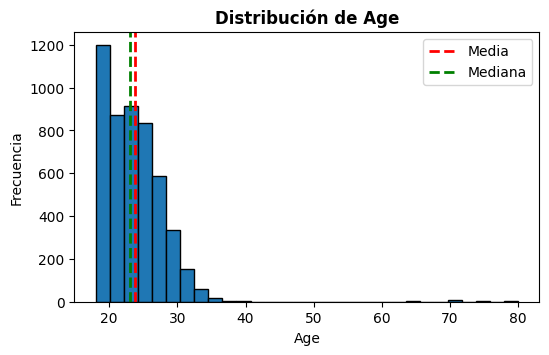

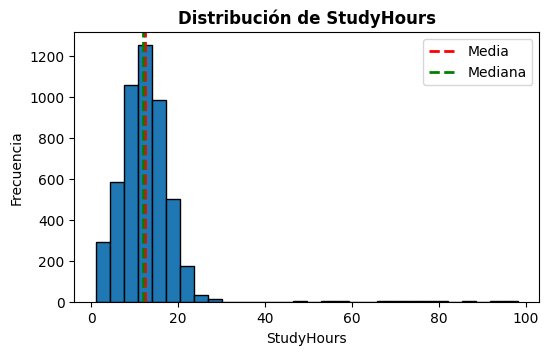

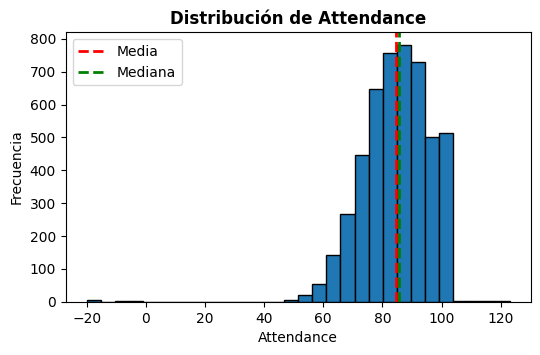

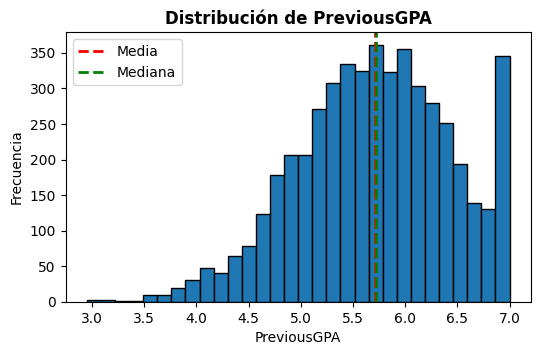

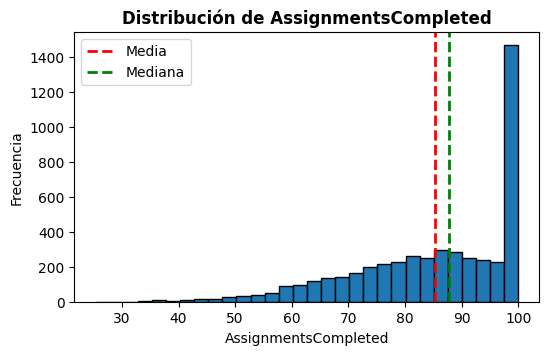

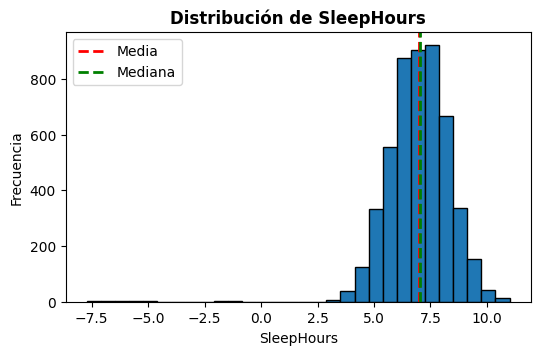

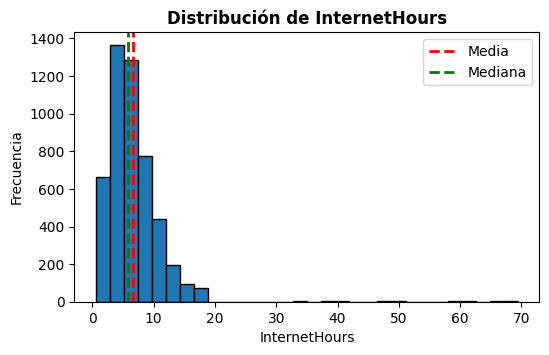

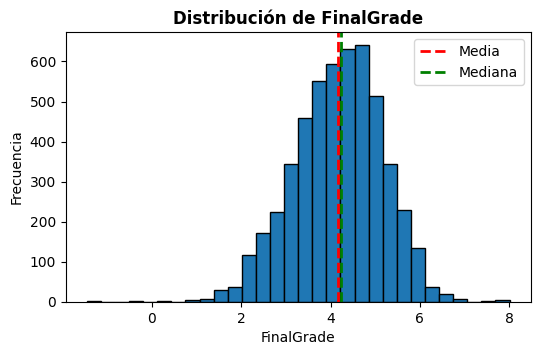

In [21]:
for variable in variables_numericas:
    plt.figure(figsize=(6, 3.5))
    plt.hist(data[variable].dropna(), bins=30, edgecolor="black")
    plt.axvline(data[variable].mean(), color="red", linestyle="dashed", linewidth=2, label="Media")
    plt.axvline(data[variable].median(), color="green", linestyle="dashed", linewidth=2, label="Mediana")
    plt.legend()
    plt.title(f"Distribución de {variable}", fontsize=12, fontweight="bold")
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")
    plt.show()

**Interpretación**

La mayoría de las variables (`StudyHours`, `Attendance`, `PreviousGPA`, `AssignmentsCompleted`, `SleepHours`) muestran una distribución razonablemente simétrica, con media y mediana muy cercanas. `Age` e `InternetHours` presentan **asimetría positiva** (cola hacia la derecha), consistente con la presencia de un grupo minoritario de estudiantes de mayor edad y de mayor consumo de internet, respectivamente. Las colas que se extienden fuera de los límites naturales de cada variable (por ejemplo, `Attendance` por debajo de 0 o por sobre 100%, o `InternetHours` por sobre 24 horas diarias) corresponden a los valores inválidos ya identificados en el diagnóstico.




## Distribución de FinalGrade

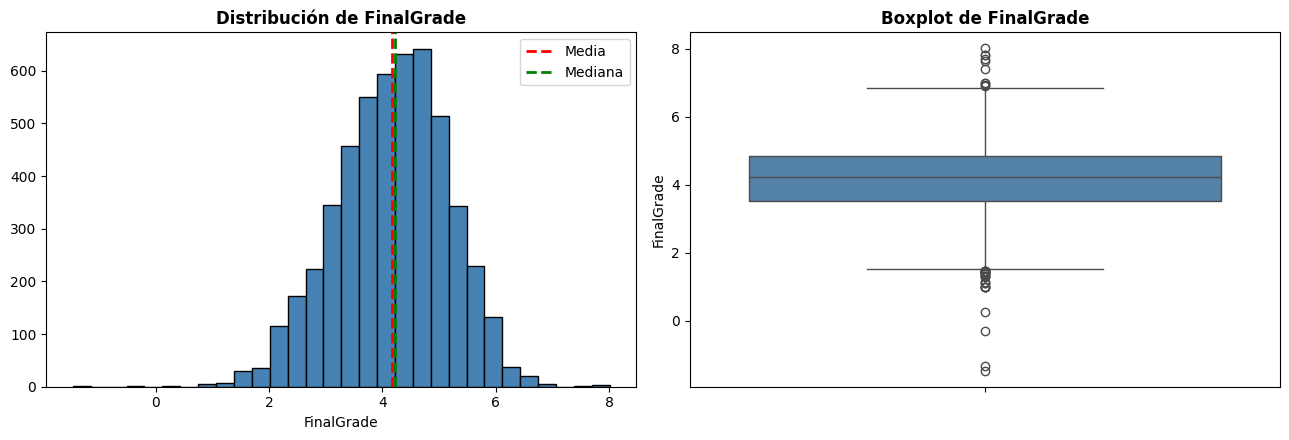

,FinalGrade
count,5100.00
mean,4.17
std,0.99
min,-1.46
25%,3.51
50%,4.23
75%,4.86
max,8.01


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(data["FinalGrade"].dropna(), bins=30, edgecolor="black", color="steelblue")
axes[0].axvline(data["FinalGrade"].mean(), color="red", linestyle="dashed", linewidth=2, label="Media")
axes[0].axvline(data["FinalGrade"].median(), color="green", linestyle="dashed", linewidth=2, label="Mediana")
axes[0].set_title("Distribución de FinalGrade", fontsize=12, fontweight="bold")
axes[0].set_xlabel("FinalGrade")
axes[0].legend()

sns.boxplot(y=data["FinalGrade"], ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot de FinalGrade", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

data["FinalGrade"].describe().round(2)

**Interpretación**

`FinalGrade` presenta una distribución levemente asimétrica hacia la izquierda, con media (4,17) algo menor que la mediana (4,23), consistente con una escala de notas 1,0–10,0 en la que la mayoría de los estudiantes se concentra entre aproximadamente 3,5 y 4,9. Se observan valores por debajo de 1,0 (mínimo de -1,46, visibles en la cola del histograma y en los puntos del boxplot fuera del "bigote" inferior), correspondientes a las 4 notas inválidas identificadas en el diagnóstico (Sección 1.4); no se registran valores por sobre 10,0 (el máximo observado es 8,01).




## Comportamiento de variables categóricas

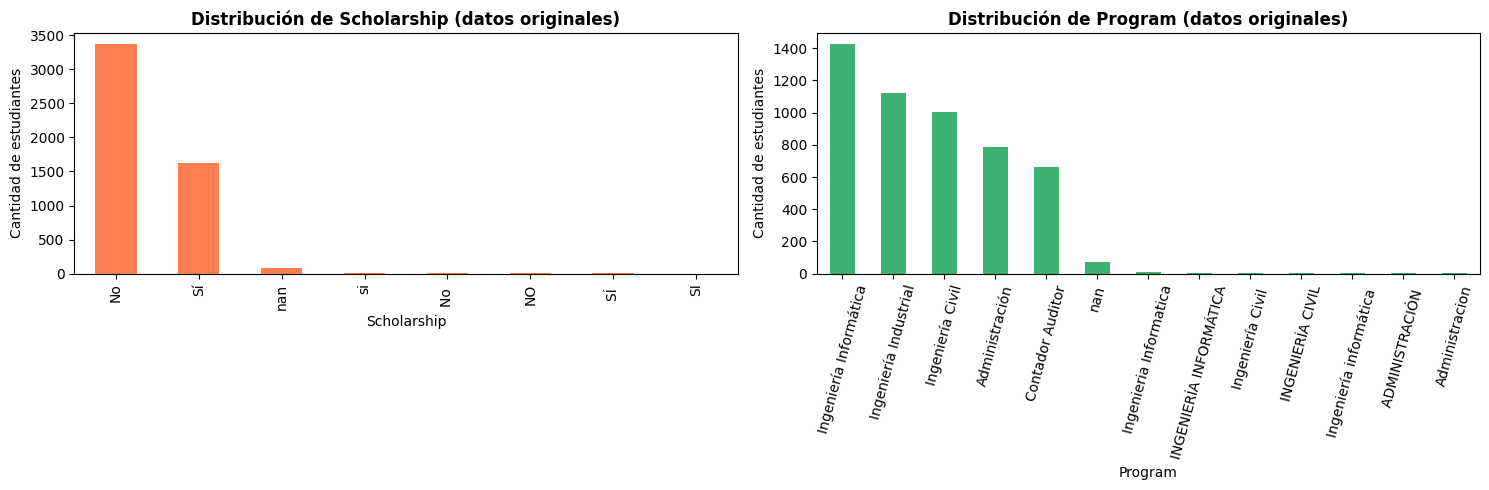

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

data["Scholarship"].value_counts(dropna=False).plot(kind="bar", ax=axes[0], color="coral")
axes[0].set_title("Distribución de Scholarship (datos originales)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Scholarship")
axes[0].set_ylabel("Cantidad de estudiantes")

data["Program"].value_counts(dropna=False).plot(kind="bar", ax=axes[1], color="mediumseagreen")
axes[1].set_title("Distribución de Program (datos originales)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Program")
axes[1].set_ylabel("Cantidad de estudiantes")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

**Interpretación**

Los gráficos muestran claramente el efecto de las inconsistencias de formato descritas en 1.4: en vez de 2 barras para `Scholarship` y 5 para `Program`, aparecen 8 y 13 barras respectivamente, con las variantes mal formateadas representando barras muy pequeñas junto a las categorías correctas. Aun así, se observa que la mayoría de los estudiantes **no posee beca** (alrededor del 66%) y que el programa con mayor matrícula es **Ingeniería Informática**, seguido de Ingeniería Industrial e Ingeniería Civil.

## Relaciones entre variables (análisis bivariado)

In [24]:
def scatter_plot(data: pd.DataFrame, x: str, y: str):
  """
  Genera un gráfico de dispersión (scatter plot) para dos variables.

  Parámetros
  ----------
  data: pd.DataFrame
    Set de datos a analizar
  x: str
    Nombre de la variable en el eje X
  y: str
    Nombre de la variable en el eje Y
  """
  plt.figure(figsize=(7, 4.5))
  plt.scatter(data[x], data[y], alpha=0.4)
  plt.xlabel(x, fontsize=12, fontweight="bold")
  plt.ylabel(y, fontsize=12, fontweight="bold")
  plt.title(f"{x} vs {y}", fontsize=13, fontweight="bold")
  plt.show()

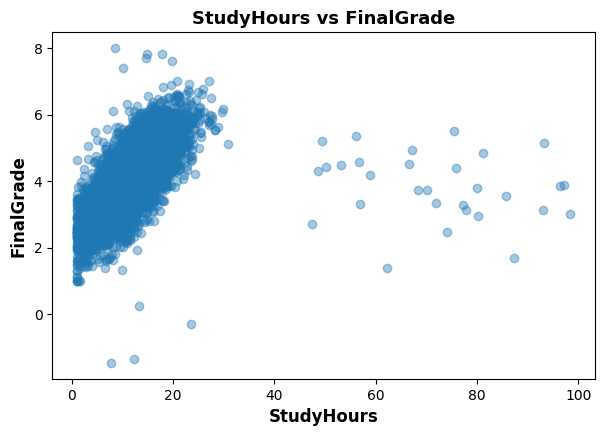

Correlación de Pearson: 0.4905


In [25]:
scatter_plot(data, "StudyHours", "FinalGrade")
print(f"Correlación de Pearson: {data['StudyHours'].corr(data['FinalGrade']):.4f}")

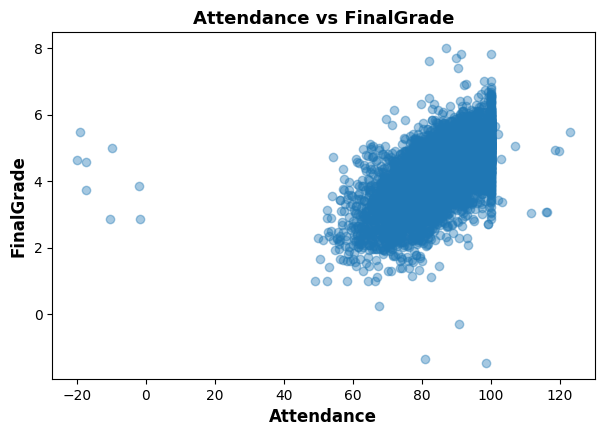

Correlación de Pearson: 0.5852


In [26]:
scatter_plot(data, "Attendance", "FinalGrade")
print(f"Correlación de Pearson: {data['Attendance'].corr(data['FinalGrade']):.4f}")

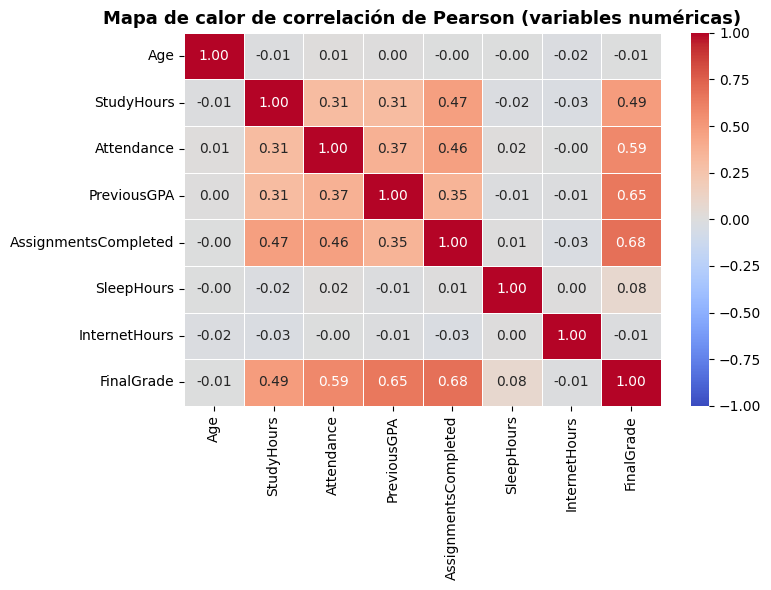

In [27]:
data_numeric = data[variables_numericas]
correlation_matrix = data_numeric.corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Mapa de calor de correlación de Pearson (variables numéricas)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretación**

`AssignmentsCompleted` (0,68) y `PreviousGPA` (0,65) son las variables con mayor correlación (positiva) con `FinalGrade`, seguidas por `Attendance` (0,59) y `StudyHours` (0,49); esto se refleja en el mapa de calor como los tonos más cálidos en la fila/columna de `FinalGrade`. `SleepHours` presenta una correlación muy baja (0,08), y `Age` e `InternetHours` son prácticamente nulas (≈ -0,01). Entre las variables predictoras, la correlación más alta se da entre `StudyHours` y `AssignmentsCompleted` (0,47), un valor moderado que no evidencia problemas serios de multicolinealidad.



## Diferencias de rendimiento según características de los estudiantes

/tmp/ipykernel_6505/686877217.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Scholarship", y="FinalGrade", data=sub_scholarship, palette="Set2")


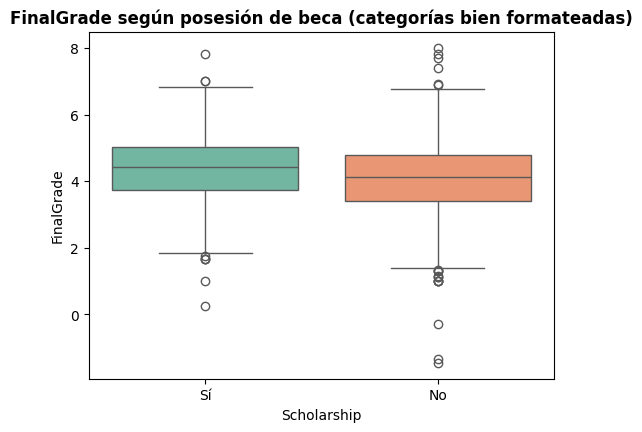

In [28]:
sub_scholarship = data[data["Scholarship"].isin(["Sí", "No"])]

plt.figure(figsize=(6, 4.5))
sns.boxplot(x="Scholarship", y="FinalGrade", data=sub_scholarship, palette="Set2")
plt.title("FinalGrade según posesión de beca (categorías bien formateadas)", fontsize=12, fontweight="bold")
plt.show()

/tmp/ipykernel_6505/1066110248.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Program", y="FinalGrade", data=sub_program, palette="Set3")


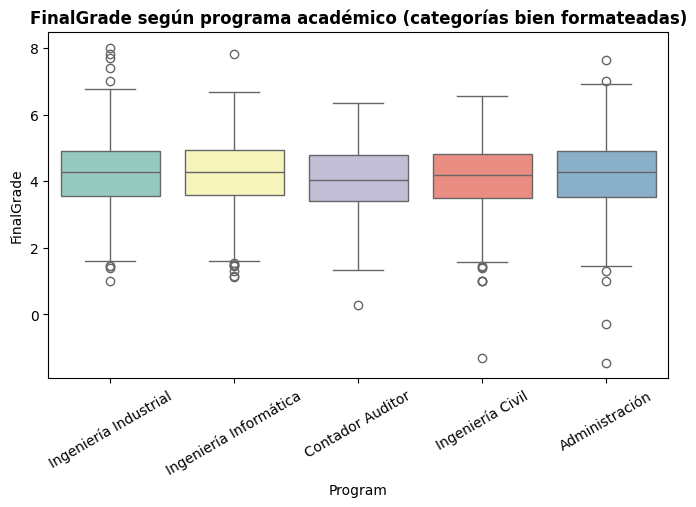

In [29]:
sub_program = data[data["Program"].isin(["Ingeniería Informática", "Ingeniería Industrial",
                                            "Ingeniería Civil", "Administración", "Contador Auditor"])]

plt.figure(figsize=(8, 4.5))
sns.boxplot(x="Program", y="FinalGrade", data=sub_program, palette="Set3")
plt.title("FinalGrade según programa académico (categorías bien formateadas)", fontsize=12, fontweight="bold")
plt.xticks(rotation=30)
plt.show()

**Interpretación**

Para estos dos gráficos se utilizó únicamente el subconjunto de registros cuya categoría ya está bien formateada (`Sí`/`No` y los 5 programas canónicos), excluyendo temporalmente los registros con variantes de formato (35 en `Scholarship` y 36 en `Program`, en conjunto menos del 1,4% del dataset), ya que consolidarlos corresponde a una decisión de tratamiento que se implementa formalmente en la Sección 4. Esta exclusión puntual no compromete las conclusiones, dado que representa una fracción mínima de los datos.

Se observa una diferencia visible en `FinalGrade` según posesión de beca (los estudiantes becados presentan notas algo más altas), y diferencias más moderadas entre programas académicos, que se cuantifican a continuación en las preguntas de investigación.

# Preguntas de investigación

## Pregunta 1 – ¿Existe diferencia en FinalGrade entre estudiantes con y sin beca?

In [30]:
resumen_beca = sub_scholarship.groupby("Scholarship")["FinalGrade"].agg(["count", "mean", "std"]).round(3)
resumen_beca

,count,mean,std
Scholarship,,,
No,3364,4.074,1.005
Sí,1620,4.371,0.932


In [31]:
diferencia_beca = (
    sub_scholarship.loc[sub_scholarship["Scholarship"] == "Sí", "FinalGrade"].mean()
    - sub_scholarship.loc[sub_scholarship["Scholarship"] == "No", "FinalGrade"].mean()
)
print(f"Diferencia de promedio (Sí - No): {diferencia_beca:.3f} puntos")

Diferencia de promedio (Sí - No): 0.297 puntos


**Respuesta:** sí existe una diferencia. Los estudiantes **con beca** (`Sí`) presentan un promedio de `FinalGrade` de **4,37**, mientras que los estudiantes **sin beca** (`No`) presentan un promedio de **4,07**. La diferencia es de **0,30 puntos** a favor de los estudiantes con beca. Considerando la desviación estándar de ambos grupos (≈ 0,93–1,00), la diferencia es discreta en relación a la dispersión de la nota, aunque consistente, y se explica en parte porque el otorgamiento de becas suele estar asociado a buen desempeño académico previo.




## Pregunta 2 – ¿Qué programa académico presenta el mayor promedio de FinalGrade y cuál es la diferencia respecto del programa que presenta el menor promedio?


In [32]:
resumen_programa = (
    sub_program.groupby("Program")["FinalGrade"]
    .agg(["count", "mean", "std"])
    .round(3)
    .sort_values("mean", ascending=False)
)
resumen_programa

,count,mean,std
Program,,,
Ingeniería Informática,1424,4.232,0.988
Administración,787,4.217,1.009
Ingeniería Industrial,1119,4.201,0.982
Ingeniería Civil,1004,4.108,0.986
Contador Auditor,660,4.045,1.003


In [33]:
diferencia_programa = resumen_programa["mean"].max() - resumen_programa["mean"].min()
print(f"Programa con mayor promedio: {resumen_programa.index[0]} ({resumen_programa['mean'].iloc[0]:.3f})")
print(f"Programa con menor promedio: {resumen_programa.index[-1]} ({resumen_programa['mean'].iloc[-1]:.3f})")
print(f"Diferencia: {diferencia_programa:.3f} puntos")

Programa con mayor promedio: Ingeniería Informática (4.232)
Programa con menor promedio: Contador Auditor (4.045)
Diferencia: 0.187 puntos


**Respuesta:** el programa con mayor promedio de `FinalGrade` es **Ingeniería Informática** (4,23), seguido muy de cerca por Administración (4,22) e Ingeniería Industrial (4,20). El programa con menor promedio es **Contador Auditor** (4,05). La diferencia entre el programa de mayor y menor promedio es de **0,18 puntos**, una diferencia pequeña que sugiere que el programa académico, por sí solo, no es un factor determinante del rendimiento final.




## Pregunta 3 – ¿Existe relación entre StudyHours y FinalGrade?

In [34]:
correlacion_study = data["StudyHours"].corr(data["FinalGrade"])
print(f"Correlación de Pearson (StudyHours vs FinalGrade): {correlacion_study:.4f}")

Correlación de Pearson (StudyHours vs FinalGrade): 0.4905


**Respuesta:** sí existe una relación **positiva** entre `StudyHours` y `FinalGrade`, con un coeficiente de correlación de Pearson de **r ≈ 0,49**. Esto indica una asociación lineal de **intensidad moderada**: a mayor cantidad de horas de estudio, tiende a observarse una mejor nota final, aunque la relación no es perfecta (existen otros factores que también influyen en el rendimiento). Esto es consistente con lo observado en el gráfico de dispersión de la sección anterior.

## Pregunta 4 – ¿Existe relación entre Attendance y FinalGrade?

In [35]:
correlacion_attendance = data["Attendance"].corr(data["FinalGrade"])
print(f"Correlación de Pearson (Attendance vs FinalGrade): {correlacion_attendance:.4f}")

Correlación de Pearson (Attendance vs FinalGrade): 0.5852


/tmp/ipykernel_6505/1012815531.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Grupo_Asistencia", y="FinalGrade", data=data_asistencia, palette="Blues")


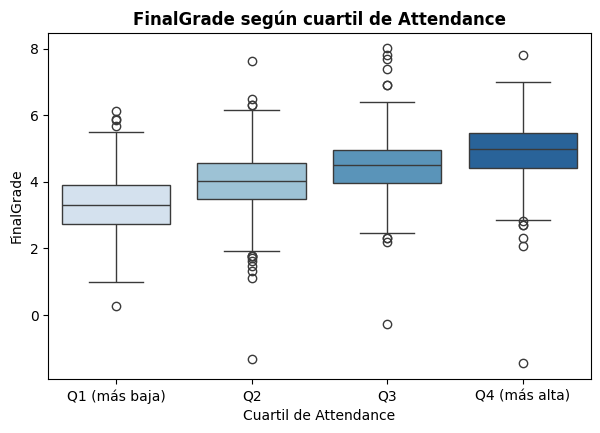

/tmp/ipykernel_6505/1012815531.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_asistencia.groupby("Grupo_Asistencia")["FinalGrade"].mean().round(3)


,FinalGrade
Grupo_Asistencia,
Q1 (más baja),3.315
Q2,4.001
Q3,4.470
Q4 (más alta),4.929


In [36]:
data_asistencia = data.dropna(subset=["Attendance", "FinalGrade"]).copy()
data_asistencia["Grupo_Asistencia"] = pd.qcut(data_asistencia["Attendance"], q=4,
                                                labels=["Q1 (más baja)", "Q2", "Q3", "Q4 (más alta)"])

plt.figure(figsize=(7, 4.5))
sns.boxplot(x="Grupo_Asistencia", y="FinalGrade", data=data_asistencia, palette="Blues")
plt.title("FinalGrade según cuartil de Attendance", fontsize=12, fontweight="bold")
plt.xlabel("Cuartil de Attendance")
plt.show()

data_asistencia.groupby("Grupo_Asistencia")["FinalGrade"].mean().round(3)

**Respuesta:** sí, existe una relación **positiva y de intensidad moderada-alta** entre `Attendance` y `FinalGrade` (r ≈ 0,59), una de las correlaciones más altas junto con `AssignmentsCompleted` (0,68) y `PreviousGPA` (0,65). El gráfico de cajas por cuartiles de asistencia confirma esta tendencia: el promedio de `FinalGrade` **aumenta de forma sostenida** desde el cuartil de asistencia más baja hasta el más alta, lo que evidencia que **los estudiantes con mayor asistencia tienden a presentar mejor rendimiento académico**.



## Interpretación del EDA – Conclusiones generales

A partir del diagnóstico y el análisis exploratorio realizado, se plantean las siguientes conclusiones:

1. **El cumplimiento de tareas y el rendimiento académico previo son los factores más asociados a `FinalGrade`, seguidos de cerca por la asistencia y las horas de estudio.** `AssignmentsCompleted` (r ≈ 0,68) y `PreviousGPA` (r ≈ 0,65) presentan las correlaciones más altas con `FinalGrade`, seguidas por `Attendance` (r ≈ 0,59) y `StudyHours` (r ≈ 0,49); el resto de las variables (`SleepHours`, `Age`, `InternetHours`) presenta correlaciones muy bajas o prácticamente nulas. Esto sugiere que tanto el desempeño académico acumulado (`PreviousGPA`) como el comportamiento del estudiante durante el curso (tareas completadas, asistencia, horas de estudio) pesan más que sus características demográficas o de estilo de vida.

2. **Poseer beca se asocia a un mejor rendimiento, con una diferencia discreta.** Los estudiantes becados obtienen en promedio 0,30 puntos más en `FinalGrade` que los no becados (4,37 vs 4,07, en escala 1,0–10,0), diferencia consistente pero pequeña en comparación con la desviación estándar de la nota (≈ 1,0).

3. **El programa académico no explica diferencias importantes de rendimiento.** La brecha entre el programa con mejor y peor promedio es de apenas 0,18 puntos, lo que indica que el rendimiento académico medido por `FinalGrade` es relativamente homogéneo entre los distintos programas, y que otros factores (tareas completadas, rendimiento previo, asistencia, horas de estudio) tienen mayor peso explicativo que la elección de carrera.




# 3. Tratamiento de los datos

A partir del diagnóstico (Sección 1) se definen las siguientes estrategias de tratamiento. **Estas decisiones se implementan recién en la Sección 4**; hasta este punto no se ha modificado el dataset original.

| Problema | Estrategia | Justificación |
| --- | --- | --- |
| Registros duplicados (100, 2,0%) | Eliminar, conservando la primera ocurrencia | Son copias exactas de otro registro (mismo `StudentID`); no aportan información nueva y distorsionarían las estadísticas y cualquier modelo posterior. |
| Inconsistencias de formato en `Scholarship` y `Program` | Normalizar mayúsculas, minúsculas, tildes y espacios, consolidando en las categorías canónicas (`Sí`/`No`; 5 programas) | Son variantes de escritura de la misma categoría, no categorías nuevas; consolidarlas evita fragmentar artificialmente los grupos. |
| Valores fuera de dominio / inválidos (`Attendance`, `SleepHours`, `InternetHours`, `StudyHours`, `PreviousGPA`, `FinalGrade`) | Recodificar a `NaN` y tratar como valor faltante (imputación) | Son valores físicamente imposibles dado el significado de cada variable (ej. asistencia negativa, más de 24 horas en un día para variables diarias, más de 168 horas en una semana para `StudyHours`, o fuera de la escala 1,0–10,0 para `PreviousGPA`/`FinalGrade`). No se pueden "corregir" adivinando el valor real, por lo que se tratan como información no disponible. |
| Valores faltantes (originales + inválidos recodificados) en variables numéricas con baja proporción de atípicos (`PreviousGPA`, `AssignmentsCompleted`, `Attendance`, `SleepHours`) | Imputar por **media** | Distribuciones razonablemente simétricas, sin atípicos severos que sesguen la media. |
| Valores faltantes en variables numéricas con mayor proporción de atípicos (`Age`, `StudyHours`, `InternetHours`) | Imputar por **mediana** | La mediana es más robusta que la media frente a la presencia de valores atípicos. |
| Valores faltantes en `Scholarship` y `Program` | Imputar por **moda** | Estrategia estándar para variables categóricas nominales. |
| Valores faltantes en `FinalGrade` (variable objetivo) | Imputar por **mediana**, de forma independiente del resto de las variables | Al ser la variable objetivo, se mantiene separada del `ColumnTransformer` de variables predictoras; se trata de forma simple y robusta (mediana) dado que también presenta valores inválidos. |
| Valores atípicos válidos (extremos pero dentro de dominio, ej. `Age` alto, `InternetHours` alto) | No eliminar; atenuar su influencia mediante `RobustScaler` en las variables `Age`, `StudyHours`, `InternetHours` | Son observaciones reales; eliminarlas implicaría pérdida de información. El escalado robusto (basado en mediana e IQR) reduce su peso sin descartarlas. |
| Variables numéricas sin atípicos severos (`PreviousGPA`, `AssignmentsCompleted`, `Attendance`, `SleepHours`) | Escalar con `StandardScaler` | Estandarización habitual para variables sin atípicos relevantes, útil para modelos sensibles a la escala. |
| Variables categóricas (`Scholarship`, `Program`) | Codificar con `OneHotEncoder` | Son variables nominales sin orden; el one-hot encoding evita imponer una relación de orden inexistente. |
| `StudentID` | Excluir del proceso de transformación | Es un identificador, sin valor predictivo. Se conserva solo como referencia en el dataset final exportado. |

No se considera necesario eliminar ninguna observación (salvo los duplicados exactos) ni ninguna columna: la proporción de problemas es baja en todos los casos (< 5%) y la imputación permite conservar el tamaño muestral.


# 4. Implementación mediante Pipeline

A continuación se implementa, de forma reproducible, el tratamiento definido en la Sección 3. El proceso se organiza en dos etapas:

1. **Limpieza a nivel de fila/valor** (duplicación, normalización de categorías, recodificación de valores inválidos a `NaN`): se implementa mediante funciones de `pandas`, ya que corresponde a reglas de negocio específicas del dominio (no a transformaciones estadísticas genéricas).
2. **Imputación, codificación y escalado**: se implementa mediante `Pipeline` y `ColumnTransformer` de scikit-learn, de forma que el proceso sea reproducible y aplicable nuevamente sobre el dataset original.

## Limpieza de filas: duplicados, formato de categóricas e inconsistencias

In [37]:
import unicodedata

def _clave(texto):
    """Normaliza un texto para comparación: sin espacios extra, mayúsculas y sin tildes."""
    t = str(texto).strip().upper()
    t = "".join(c for c in unicodedata.normalize("NFKD", t) if not unicodedata.combining(c))
    return t

mapa_program = {
    "INGENIERIA INDUSTRIAL": "Ingeniería Industrial",
    "INGENIERIA INFORMATICA": "Ingeniería Informática",
    "CONTADOR AUDITOR": "Contador Auditor",
    "INGENIERIA CIVIL": "Ingeniería Civil",
    "ADMINISTRACION": "Administración",
}
mapa_scholarship = {"SI": "Sí", "NO": "No"}


def normalizar_categoricas(df: pd.DataFrame) -> pd.DataFrame:
    """Consolida variantes de formato (mayúsculas, tildes, espacios) en las categorías canónicas."""
    df = df.copy()
    df["Program"] = df["Program"].apply(lambda x: mapa_program.get(_clave(x), x) if pd.notna(x) else x)
    df["Scholarship"] = df["Scholarship"].apply(lambda x: mapa_scholarship.get(_clave(x), x) if pd.notna(x) else x)
    return df


def tratar_inconsistencias(df: pd.DataFrame) -> pd.DataFrame:
    """Recodifica como NaN los valores fuera del dominio válido de cada variable."""
    df = df.copy()
    reglas = [
        ("Attendance", 0, 100),
        ("SleepHours", 0, 24),
        ("InternetHours", 0, 24),
        ("StudyHours", 0, 168),
        ("PreviousGPA", 1, 10),
        ("FinalGrade", 1, 10),
    ]
    for columna, minimo, maximo in reglas:
        mask = (df[columna] < minimo) | (df[columna] > maximo)
        df.loc[mask, columna] = np.nan
    return df


def preparar_dataset(df_original: pd.DataFrame) -> pd.DataFrame:
    """
    Función reproducible: recibe el dataset original (crudo) y retorna
    el dataset con duplicados eliminados, categorías normalizadas y
    valores inválidos recodificados como NaN (listo para imputar).
    """
    df = df_original.drop_duplicates().copy()
    df = normalizar_categoricas(df)
    df = tratar_inconsistencias(df)
    return df.reset_index(drop=True)


data_prep = preparar_dataset(data)
print(f"Registros originales: {data.shape[0]} -> Registros tras eliminar duplicados: {data_prep.shape[0]}")
data_prep.isnull().sum()


Registros originales: 5100 -> Registros tras eliminar duplicados: 5000


,0
StudentID,0
Age,100
StudyHours,180
Attendance,240
PreviousGPA,160
AssignmentsCompleted,210
SleepHours,128
InternetHours,200
Scholarship,80
Program,70


In [38]:
print("Scholarship tras normalización:", sorted(data_prep["Scholarship"].dropna().unique()))
print("Program tras normalización:", sorted(data_prep["Program"].dropna().unique()))

Scholarship tras normalización: ['No', 'Sí']
Program tras normalización: ['Administración', 'Contador Auditor', 'Ingeniería Civil', 'Ingeniería Industrial', 'Ingeniería Informática']


## Separación de variables predictoras (X) y variable objetivo (y)

In [39]:
student_id = data_prep["StudentID"]
X = data_prep.drop(columns=["StudentID", "FinalGrade"])
y = data_prep["FinalGrade"]

X.shape, y.shape

((5000, 10), (5000,))

## Tratamiento de la variable objetivo (FinalGrade)

In [40]:
# FinalGrade se mantiene separada del resto de las variables durante la transformación.
# Sus valores inválidos ya fueron recodificados a NaN en preparar_dataset(); se imputan
# de forma independiente, por mediana (robusta frente a los valores inválidos previos).
imputer_y = SimpleImputer(strategy="median")
y_imputado = pd.Series(imputer_y.fit_transform(y.values.reshape(-1, 1)).ravel(), name="FinalGrade")

print(f"Valores faltantes en FinalGrade antes de imputar: {y.isnull().sum()}")
print(f"Valores faltantes en FinalGrade después de imputar: {y_imputado.isnull().sum()}")

Valores faltantes en FinalGrade antes de imputar: 4
Valores faltantes en FinalGrade después de imputar: 0


## Definición de sub-pipelines por tipo de variable

In [41]:
# A. Variables numéricas sin atípicos severos -> imputación por media + StandardScaler
num_standard_features = ["PreviousGPA", "AssignmentsCompleted", "Attendance", "SleepHours"]
num_standard_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

# B. Variables numéricas con mayor proporción de atípicos -> imputación por mediana + RobustScaler
num_robust_features = ["Age", "StudyHours", "InternetHours"]
num_robust_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]
)

# C. Variables categóricas -> imputación por moda + One-Hot Encoding
categorical_features = ["Scholarship", "Program"]
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# Integración con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num_std", num_standard_pipeline, num_standard_features),
        ("num_robust", num_robust_pipeline, num_robust_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)
preprocessor

ColumnTransformer(transformers=[('num_std',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['PreviousGPA', 'AssignmentsCompleted',
                                  'Attendance', 'SleepHours']),
                                ('num_robust',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['Age', 'StudyHours', 'InternetHours']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Scholarship', 'Program'])])

## Ajuste y transformación de los datos

In [42]:
X_processed = preprocessor.fit_transform(X)

# Nombres de columnas resultantes
encoded_cat_cols = (
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = num_standard_features + num_robust_features + list(encoded_cat_cols)

X_prep = pd.DataFrame(X_processed, columns=all_feature_names)
print(f"Dimensión de X tratado: {X_prep.shape}")
X_prep.head()

Dimensión de X tratado: (5000, 14)


,PreviousGPA,AssignmentsCompleted,Attendance,SleepHours,Age,StudyHours,InternetHours,Scholarship_No,Scholarship_Sí,Program_Administración,Program_Contador Auditor,Program_Ingeniería Civil,Program_Ingeniería Industrial,Program_Ingeniería Informática
0,0.525754,-1.154173,-0.096829,-0.601737,-0.2,-0.205894,-0.324698,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.456325,-0.593760,1.464960,-0.397124,8.4,-0.337917,0.513529,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.497976,0.774224,0.781001,-0.249803,0.6,0.223183,0.131261,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.863157,0.412830,-0.293652,-0.691766,0.8,1.376817,0.002303,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-1.210384,-1.509820,-1.431289,-0.577183,-0.6,-0.902161,-0.391480,1.0,0.0,0.0,0.0,1.0,0.0,0.0


# 5. Dataset final y evidencia

## Construcción del DataFrame final

In [43]:
data_tratado = pd.concat(
    [
        student_id.reset_index(drop=True),
        X_prep,
        y_imputado,
    ],
    axis=1,
)

print(f"Dimensión del dataset tratado: {data_tratado.shape}")
data_tratado.head()

Dimensión del dataset tratado: (5000, 16)


,StudentID,PreviousGPA,AssignmentsCompleted,Attendance,SleepHours,Age,StudyHours,InternetHours,Scholarship_No,Scholarship_Sí,Program_Administración,Program_Contador Auditor,Program_Ingeniería Civil,Program_Ingeniería Industrial,Program_Ingeniería Informática,FinalGrade
0,STU-10522,0.525754,-1.154173,-0.096829,-0.601737,-0.2,-0.205894,-0.324698,0.0,1.0,0.0,0.0,0.0,1.0,0.0,3.96
1,STU-10947,1.456325,-0.593760,1.464960,-0.397124,8.4,-0.337917,0.513529,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.09
2,STU-11352,0.497976,0.774224,0.781001,-0.249803,0.6,0.223183,0.131261,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4.37
3,STU-12298,-0.863157,0.412830,-0.293652,-0.691766,0.8,1.376817,0.002303,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4.02
4,STU-13527,-1.210384,-1.509820,-1.431289,-0.577183,-0.6,-0.902161,-0.391480,1.0,0.0,0.0,0.0,1.0,0.0,0.0,3.24


## Verificación de calidad del dataset tratado

In [44]:
# 1. Valores faltantes
print("Valores faltantes en el dataset tratado:", data_tratado.isnull().sum().sum())

# 2. Registros duplicados
print("Registros duplicados en el dataset tratado:", data_tratado.duplicated().sum())

Valores faltantes en el dataset tratado: 0
Registros duplicados en el dataset tratado: 0


In [45]:
# 3. Verificación de que las inconsistencias de dominio fueron corregidas.
# Como las variables numéricas predictoras quedaron escaladas (Standard/RobustScaler),
# la verificación de dominio (0-100, 0-24, 0-168, 1-10, etc.) se realiza sobre una versión
# imputada EN LAS UNIDADES ORIGINALES, aplicando exactamente la misma estrategia de
# imputación (media/mediana/moda) usada dentro del Pipeline, antes de escalar.
verif = X.copy()
for col in num_standard_features:
    verif[col] = verif[col].fillna(verif[col].mean())
for col in num_robust_features:
    verif[col] = verif[col].fillna(verif[col].median())
for col in categorical_features:
    verif[col] = verif[col].fillna(verif[col].mode()[0])

fuera_de_dominio = (
    ((verif["Attendance"] < 0) | (verif["Attendance"] > 100)).sum()
    + ((verif["SleepHours"] < 0) | (verif["SleepHours"] > 24)).sum()
    + ((verif["InternetHours"] < 0) | (verif["InternetHours"] > 24)).sum()
    + ((verif["StudyHours"] < 0) | (verif["StudyHours"] > 168)).sum()
    + ((verif["PreviousGPA"] < 1) | (verif["PreviousGPA"] > 10)).sum()
    + ((y_imputado < 1) | (y_imputado > 10)).sum()
)
print(f"Valores fuera de dominio remanentes (en unidades originales, tras imputación): {fuera_de_dominio}")
print(f"Categorías únicas en Scholarship: {sorted(verif['Scholarship'].unique())}")
print(f"Categorías únicas en Program: {sorted(verif['Program'].unique())}")


Valores fuera de dominio remanentes (en unidades originales, tras imputación): 0
Categorías únicas en Scholarship: ['No', 'Sí']
Categorías únicas en Program: ['Administración', 'Contador Auditor', 'Ingeniería Civil', 'Ingeniería Industrial', 'Ingeniería Informática']


**Verificación:** el dataset tratado no presenta valores faltantes ni registros duplicados. Las variables `Attendance`, `SleepHours`, `InternetHours`, `StudyHours` y `FinalGrade`, una vez imputadas en sus unidades originales, quedan dentro de su dominio válido (0 valores fuera de rango), y `Scholarship`/`Program` quedan reducidas a sus categorías canónicas (2 y 5, respectivamente). Los problemas identificados en el diagnóstico inicial fueron corregidos según las estrategias definidas en la Sección 3.

## Comparación entre dataset original y dataset tratado

In [46]:
comparacion = pd.DataFrame({
    "Indicador": [
        "Cantidad de registros",
        "Cantidad de variables",
        "Valores faltantes (total)",
        "Registros duplicados",
        "Inconsistencias (valores fuera de dominio)",
        "Outliers inválidos tratados",
    ],
    "Dataset original": [
        data.shape[0],
        data.shape[1],
        int(data.isnull().sum().sum()),
        int(data.duplicated().sum()),
        int(regla_attendance.sum() + regla_sleep.sum() + regla_internet.sum() + regla_study.sum() + regla_gpa.sum() + regla_finalgrade.sum()),
        int(regla_attendance.sum() + regla_sleep.sum() + regla_internet.sum() + regla_study.sum() + regla_gpa.sum() + regla_finalgrade.sum()),
    ],
    "Dataset tratado": [
        data_tratado.shape[0],
        data_tratado.shape[1],
        int(data_tratado.isnull().sum().sum()),
        int(data_tratado.duplicated().sum()),
        int(fuera_de_dominio),
        0,
    ],
})
comparacion


,Indicador,Dataset original,Dataset tratado
0,Cantidad de registros,5100,5000
1,Cantidad de variables,12,16
2,Valores faltantes (total),1335,0
3,Registros duplicados,100,0
4,Inconsistencias (valores fuera de dominio),63,0
5,Outliers inválidos tratados,63,0


**Nota sobre outliers:** los *valores inválidos* (fuera de dominio, ver tabla anterior) fueron corregidos mediante recodificación a `NaN` e imputación. Los *valores atípicos válidos* (extremos pero dentro de dominio, ej. estudiantes de mayor edad o mayor uso de internet) **no fueron eliminados** — se mantienen como observaciones reales, y su influencia se atenúa mediante `RobustScaler` en las variables `Age`, `StudyHours` e `InternetHours` dentro del Pipeline.

Adicionalmente, el dataset tratado pasa de 11 a 16 columnas: se elimina la ambigüedad de columnas categóricas duplicadas y se agregan las columnas dummy generadas por el `OneHotEncoder` (2 para `Scholarship` + 5 para `Program`), quedando el dataset listo para ser utilizado por un modelo predictivo.

## Exportación del dataset tratado

In [47]:
data_tratado.to_csv("rendimiento_academico_limpio.csv", index=False)
print("Archivo 'rendimiento_academico_limpio.csv' exportado correctamente.")
print(f"Dimensión final: {data_tratado.shape}")

Archivo 'rendimiento_academico_limpio.csv' exportado correctamente.
Dimensión final: (5000, 16)


## Verificación de reproducibilidad

El proceso completo puede ejecutarse nuevamente sobre el dataset original (`data`) llamando a `preparar_dataset(data)` y volviendo a ajustar el `preprocessor`, obteniendo el mismo resultado. Esto permite aplicar exactamente el mismo tratamiento sobre nuevos datos (por ejemplo, una nueva cohorte de estudiantes) sin necesidad de repetir manualmente cada paso.